In [2]:
# ============================================================
# AUTO EMAIL / TICKET CATEGORIZER


import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

## Load and inspect dataset

In [3]:
df = pd.read_csv('/content/ticket_categorizer.csv')

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDepartment Distribution:")
print(df['department'].value_counts())

Dataset Shape: (998, 3)

Columns:
['ticket_id', 'ticket_text', 'department']

Missing Values:
ticket_id      0
ticket_text    0
department     0
dtype: int64

Duplicate Rows:
0

Department Distribution:
department
hr           250
general      250
technical    249
billing      249
Name: count, dtype: int64


## Text preprocessing

In [4]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [5]:
df['clean_text'] = df['ticket_text'].apply(clean_text)

In [6]:
X = df['clean_text']
y = df['department']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 798
Testing samples : 200


In [8]:
pipeline = Pipeline([
    (
        'tfidf',
        TfidfVectorizer(
            ngram_range=(1, 2),
            sublinear_tf=True
        )
    ),

    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [9]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

Test Accuracy : 1.0000
Macro F1       : 1.0000

Classification Report:
              precision    recall  f1-score   support

     billing      1.000     1.000     1.000        50
     general      1.000     1.000     1.000        50
          hr      1.000     1.000     1.000        50
   technical      1.000     1.000     1.000        50

    accuracy                          1.000       200
   macro avg      1.000     1.000     1.000       200
weighted avg      1.000     1.000     1.000       200



Confusion Matrix:
[[50  0  0  0]
 [ 0 50  0  0]
 [ 0  0 50  0]
 [ 0  0  0 50]]


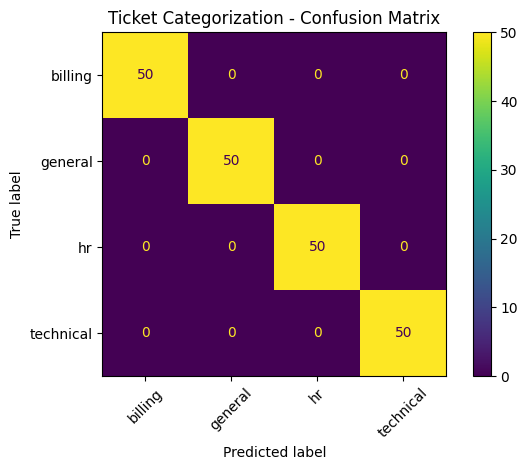

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=pipeline.classes_
)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_
).plot(
    xticks_rotation=45
)

plt.title("Ticket Categorization - Confusion Matrix")
plt.tight_layout()
plt.show()

## lightweight GridSearchCV

In [13]:
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2],
    'classifier__C': [0.5, 1, 2]
}

In [14]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.5, 1, 2], 'tfidf__min_df': [1, 2],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro')

In [15]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest 5-Fold CV Macro F1:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__C': 1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

Best 5-Fold CV Macro F1:
0.9975


In [16]:
best_model = grid_search.best_estimator_

In [17]:
y_pred = best_model.predict(X_test)

print("\nFinal Test Performance:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)


Final Test Performance:
              precision    recall  f1-score   support

     billing      1.000     1.000     1.000        50
     general      1.000     1.000     1.000        50
          hr      1.000     1.000     1.000        50
   technical      1.000     1.000     1.000        50

    accuracy                          1.000       200
   macro avg      1.000     1.000     1.000       200
weighted avg      1.000     1.000     1.000       200



In [18]:
# Confident Score

def predict_ticket(subject, body):

    # Combine subject and body
    text = f"{subject} {body}"

    # Clean text
    text = clean_text(text)

    # Predict class
    prediction = best_model.predict([text])[0]

    # Get probabilities
    probabilities = best_model.predict_proba([text])[0]

    # Highest probability
    confidence = probabilities.max()

    return prediction, confidence

In [19]:
#Human review threshold
CONFIDENCE_THRESHOLD = 0.60


In [20]:
def process_ticket(subject, body):

    # ------------------------------------------------
    # 1. Combine subject and body
    # ------------------------------------------------
    text = f"{subject} {body}"

    # ------------------------------------------------
    # 2. Clean text
    # ------------------------------------------------
    cleaned_text = clean_text(text)

    # ------------------------------------------------
    # 3. Handle extremely short/empty ticket
    # ------------------------------------------------
    if len(cleaned_text.split()) < 2:
        return {
            'category': 'unknown',
            'confidence': 0.0,
            'priority': 'NORMAL',
            'decision': 'NEEDS HUMAN REVIEW',
            'route_to': 'Manual Review Queue'
        }

    # ------------------------------------------------
    # 4. Model prediction
    # ------------------------------------------------
    prediction = best_model.predict([cleaned_text])[0]

    probabilities = best_model.predict_proba(
        [cleaned_text]
    )[0]

    confidence = probabilities.max()

    # ------------------------------------------------
    # 5. Priority detection
    # ------------------------------------------------
    priority_keywords = [
        'urgent',
        'asap',
        'critical',
        'emergency',
        'down',
        'not working',
        'cannot access',
        'unable to access'
    ]

    priority = (
        'URGENT'
        if any(
            word in cleaned_text
            for word in priority_keywords
        )
        else 'NORMAL'
    )

    # ------------------------------------------------
    # 6. Human review / auto-routing
    # ------------------------------------------------
    if confidence < CONFIDENCE_THRESHOLD:

        decision = 'NEEDS HUMAN REVIEW'
        route = 'Manual Review Queue'

    else:

        decision = 'AUTO-ASSIGN'

        routing_map = {
            'billing': 'Billing Department',
            'technical': 'Technical Support',
            'hr': 'HR Department',
            'general': 'General Support'
        }

        route = routing_map[prediction]

    # ------------------------------------------------
    # 7. Final result
    # ------------------------------------------------
    return {
        'category': prediction,
        'confidence': round(confidence * 100, 2),
        'priority': priority,
        'decision': decision,
        'route_to': route
    }

In [21]:
result = process_ticket(
    "Refund not received",
    "I cancelled my purchase several days ago but the money has not been returned."
)

print(result)

{'category': 'billing', 'confidence': np.float64(53.14), 'priority': 'NORMAL', 'decision': 'NEEDS HUMAN REVIEW', 'route_to': 'Manual Review Queue'}


In [22]:
result = process_ticket(
    "Application problem",
    "The application keeps crashing whenever I try to open my account."
)

print(result)

{'category': 'technical', 'confidence': np.float64(80.01), 'priority': 'NORMAL', 'decision': 'AUTO-ASSIGN', 'route_to': 'Technical Support'}


In [23]:
result = process_ticket(
    "Leave request",
    "I need to take two days off next month. How can I submit my leave request?"
)

print(result)

{'category': 'hr', 'confidence': np.float64(59.78), 'priority': 'NORMAL', 'decision': 'NEEDS HUMAN REVIEW', 'route_to': 'Manual Review Queue'}


In [24]:
result = process_ticket(
    "Product information",
    "Can you tell me more about the services and plans you provide?"
)

print(result)

{'category': 'general', 'confidence': np.float64(94.19), 'priority': 'NORMAL', 'decision': 'AUTO-ASSIGN', 'route_to': 'General Support'}


In [26]:
result = process_ticket(
    "Help",
    "Something is wrong. Please help me."
)

print(result)

{'category': 'billing', 'confidence': np.float64(39.31), 'priority': 'NORMAL', 'decision': 'NEEDS HUMAN REVIEW', 'route_to': 'Manual Review Queue'}


## At least 5 unseen tickets

In [27]:
unseen_tickets = [
    (
        "Unexpected transaction",
        "I noticed an unfamiliar charge on my account."
    ),

    (
        "Login failure",
        "My credentials are correct but the sign-in page won't let me continue."
    ),

    (
        "Employee information",
        "I recently changed my bank and need to update my salary account."
    ),

    (
        "About your company",
        "I would like to understand what products and services your company offers."
    ),

    (
        "Payment problem",
        "The same purchase appears twice on my account statement."
    ),

    (
        "System unavailable",
        "Our application is not responding and users cannot access the service."
    ),

    (
        "Vacation request",
        "I need to take some time off next week. What is the procedure?"
    ),

    (
        "Available plans",
        "Could you explain the different plans available to customers?"
    )
]

In [28]:
for i, (subject, body) in enumerate(
    unseen_tickets,
    start=1
):

    result = process_ticket(subject, body)

    print(f"\nTicket {i}")
    print("Subject    :", subject)
    print("Category   :", result['category'])
    print("Confidence :", f"{result['confidence']:.2f}%")
    print("Priority   :", result['priority'])
    print("Decision   :", result['decision'])
    print("Route to   :", result['route_to'])


Ticket 1
Subject    : Unexpected transaction
Category   : billing
Confidence : 77.90%
Priority   : NORMAL
Decision   : AUTO-ASSIGN
Route to   : Billing Department

Ticket 2
Subject    : Login failure
Category   : technical
Confidence : 65.04%
Priority   : NORMAL
Decision   : AUTO-ASSIGN
Route to   : Technical Support

Ticket 3
Subject    : Employee information
Category   : hr
Confidence : 71.35%
Priority   : NORMAL
Decision   : AUTO-ASSIGN
Route to   : HR Department

Ticket 4
Subject    : About your company
Category   : general
Confidence : 91.34%
Priority   : NORMAL
Decision   : AUTO-ASSIGN
Route to   : General Support

Ticket 5
Subject    : Payment problem
Category   : billing
Confidence : 59.76%
Priority   : NORMAL
Decision   : NEEDS HUMAN REVIEW
Route to   : Manual Review Queue

Ticket 6
Subject    : System unavailable
Category   : technical
Confidence : 61.66%
Priority   : URGENT
Decision   : AUTO-ASSIGN
Route to   : Technical Support

Ticket 7
Subject    : Vacation request
Categ

## Mini live CLI

In [30]:
print("\n" + "=" * 60)
print("       AUTO EMAIL / TICKET CATEGORIZER")
print("=" * 60)

subject = input("Enter ticket subject: ")
body = input("Enter ticket body: ")

result = process_ticket(subject, body)

print("\n--- Classification Result ---")
print("Category   :", result['category'])
print("Confidence :", f"{result['confidence']:.2f}%")
print("Priority   :", result['priority'])
print("Decision   :", result['decision'])
print("Route to   :", result['route_to'])


       AUTO EMAIL / TICKET CATEGORIZER
Enter ticket subject: Payment charged twice
Enter ticket body: I made one purchase but my account was charged two times

--- Classification Result ---
Category   : billing
Confidence : 89.47%
Priority   : NORMAL
Decision   : AUTO-ASSIGN
Route to   : Billing Department
